##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================
# Exercise 1 Solution
# =========================

from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import torch
import os
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.stats import mode


# Load model
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
model = AutoModel.from_pretrained("facebook/dinov2-small")

model.eval()

# Dataset path
data_dir = "/content/drive/MyDrive/data"

features = []
labels = []

# Read images directly from folder
for image_name in os.listdir(data_dir):

    image_path = os.path.join(data_dir, image_name)

    # Skip non-images
    if not image_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    try:
        image = Image.open(image_path).convert("RGB")

        inputs = processor(images=image, return_tensors="pt")

        with torch.no_grad():
            outputs = model(**inputs)

        # CLS token
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()

        features.append(cls_embedding)

        # Label from filename
        if image_name.startswith("cat"):
            labels.append(0)
        elif image_name.startswith("dog"):
            labels.append(1)

    except Exception as e:
        print("Error:", image_name, e)

# Convert to numpy
X = np.array(features)
y = np.array(labels)

print("Feature shape:", X.shape)

# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# Align cluster labels
mapping = {}

for i in range(2):
    mask = cluster_labels == i
    mapping[i] = mode(y[mask], keepdims=True).mode[0]

predicted = np.array([mapping[c] for c in cluster_labels])

# Accuracy
acc = accuracy_score(y, predicted)

print("Clustering Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Feature shape: (4, 384)
Clustering Accuracy: 0.75


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

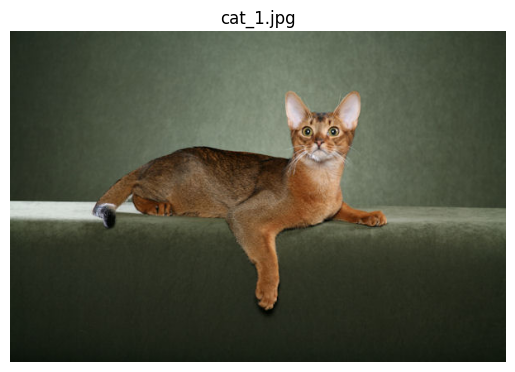

Top Predictions:

Egyptian cat : 0.9584
tiger cat : 0.0051
lynx, catamount : 0.0038
tennis ball : 0.0037
tabby, tabby cat : 0.0026


In [3]:
# =========================
# Exercise 2 Solution
# =========================

from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load classifier
classifier = pipeline(
    "image-classification",
    model="facebook/dinov2-small-imagenet1k-1-layer"
)

# Dataset path
data_dir = "/content/drive/MyDrive/data"

# Pick first image
sample_image_name = os.listdir(data_dir)[0]
sample_image_path = os.path.join(data_dir, sample_image_name)

# Load image
image = Image.open(sample_image_path).convert("RGB")

# Predict
predictions = classifier(image)

# Show image
plt.imshow(image)
plt.axis("off")
plt.title(sample_image_name)
plt.show()

# Print predictions
print("Top Predictions:\n")

for pred in predictions[:5]:
    print(f"{pred['label']} : {pred['score']:.4f}")